<a href="https://colab.research.google.com/github/ClPRlAN/nasdaq-financial-data-analysis/blob/main/nasdaq_financial_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring Financial Data with the Nasdaq Data Link API

## Introduction

This project explores financial data retrieved from the Nasdaq Data Link API using Python. The analysis focuses on the **Accrued Expenses Turnover** financial metric and examines how this metric changes over time for different companies.

The main objectives are to retrieve financial data through an API, transform the JSON response into a Pandas DataFrame, clean and filter the dataset, analyze financial trends from 2010 to 2015, compare results across geographical regions, and visualize the findings using Matplotlib.


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata

api_key = userdata.get('NASDAQ_API_KEY')

print("Libraries imported and API key loaded successfully.")

Libraries imported and API key loaded successfully.


## Nasdaq Data Link API

For this project, the financial data is retrieved from the `MER/F1` table using the Nasdaq Data Link Tables API.

The API allows parameters to filter rows, select specific columns, and control the number of results returned. For this first request, only 10 rows will be retrieved so that the JSON response can be inspected easily.

Authenticated users have higher API usage limits than anonymous users, so the API key is included with each request.


In [2]:
api_url = "https://data.nasdaq.com/api/v3/datatables/MER/F1.json"

params = {
    "api_key": api_key,
    "qopts.per_page": 10
}

response = requests.get(api_url, params=params)

print("Status code:", response.status_code)

json_data = response.json()

print("Rows returned:", len(json_data["datatable"]["data"]))
print("Columns returned:", len(json_data["datatable"]["columns"]))

print("\nColumn names:")
print([column["name"] for column in json_data["datatable"]["columns"]])

print("\nFirst row:")
print(json_data["datatable"]["data"][0])

Status code: 200
Rows returned: 10
Columns returned: 32

Column names:
['compnumber', 'reportid', 'mapcode', 'amount', 'reportdate', 'reporttype', 'auditorstatus', 'currency', 'consolidated', 'longname', 'shortname', 'status', 'countrycode', 'region', 'cik', 'mic', 'ticker', 'exchange', 'address1', 'address2', 'address3', 'address4', 'city', 'statecode', 'country', 'zipcode', 'phonenumber', 'faxnumber', 'website', 'fye', 'indicator', 'statement']

First row:
[2438, 1868192544, -1802, 10.481948, '2011-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2025-12-31', 'Accrued Expenses Turnover', 'Derived']


## Processing the JSON Data

The API response contains the financial data inside the `data` section and the corresponding column information inside the `columns` section.

To make the dataset easier to analyze, the JSON response will be converted into a Pandas DataFrame.


In [3]:
params["qopts.per_page"] = 10000

response = requests.get(api_url, params=params)
json_data = response.json()

data = json_data["datatable"]["data"]

columns = [
    column["name"]
    for column in json_data["datatable"]["columns"]
]

df_metric = pd.DataFrame(data, columns=columns)

df_metric.head()

,compnumber,reportid,mapcode,amount,reportdate,reporttype,auditorstatus,currency,consolidated,longname,...,city,statecode,country,zipcode,phonenumber,faxnumber,website,fye,indicator,statement
0,2438,1868192544,-1802,10.481948,2011-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2025-12-31,Accrued Expenses Turnover,Derived
1,2438,1868216112,-1802,8.161754,2011-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2025-12-31,Accrued Expenses Turnover,Derived
2,2438,1885063456,-1802,10.788213,2012-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2025-12-31,Accrued Expenses Turnover,Derived
3,2438,1885087024,-1802,9.437545,2012-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2025-12-31,Accrued Expenses Turnover,Derived
4,2438,1901934112,-1802,8.755041,2013-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2025-12-31,Accrued Expenses Turnover,Derived


## Understanding the Dataset

Before starting the analysis, it is useful to inspect the structure of the DataFrame and identify the columns that are relevant for the project.

The main columns needed are:

* `indicator`: identifies the financial metric.
* `country`: identifies the country of the company.
* `longname`: contains the company name.
* `reportdate`: contains the reporting date.
* `reporttype`: identifies the type of financial report.
* `amount`: contains the value of the financial metric.

These columns are important because they allow us to compare companies, analyze changes over time, and compare results between countries.


In [4]:
print("DataFrame shape:", df_metric.shape)

df_metric.info()

DataFrame shape: (10000, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   compnumber     10000 non-null  int64  
 1   reportid       10000 non-null  int64  
 2   mapcode        10000 non-null  int64  
 3   amount         10000 non-null  float64
 4   reportdate     10000 non-null  object 
 5   reporttype     10000 non-null  object 
 6   auditorstatus  9999 non-null   object 
 7   currency       10000 non-null  object 
 8   consolidated   10000 non-null  object 
 9   longname       10000 non-null  object 
 10  shortname      10000 non-null  object 
 11  status         10000 non-null  object 
 12  countrycode    10000 non-null  object 
 13  region         10000 non-null  object 
 14  cik            10000 non-null  int64  
 15  mic            10000 non-null  object 
 16  ticker         9380 non-null   object 
 17  exchange       10000 n

In [5]:
necessary_columns = [
    "indicator",
    "country",
    "longname",
    "reportdate",
    "reporttype",
    "amount"
]

necessary_columns

['indicator', 'country', 'longname', 'reportdate', 'reporttype', 'amount']

## Filtering the Data

The dataset contains many different financial indicators. Since this project focuses on `Accrued Expenses Turnover`, the DataFrame will be filtered to keep only the relevant columns and rows for this specific metric.


In [6]:
filtered_df = df_metric[necessary_columns].copy()

filtered_df = filtered_df[
    filtered_df["indicator"] == "Accrued Expenses Turnover"
]

filtered_df.head()

,indicator,country,longname,reportdate,reporttype,amount
0,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2011-06-30,Q2,10.481948
1,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2011-09-30,Q3,8.161754
2,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2012-06-30,Q2,10.788213
3,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2012-09-30,Q3,9.437545
4,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2013-06-30,Q2,8.755041


In [7]:
filtered_df["amount"].describe()

,amount
count,139.000000
mean,26.908762
std,33.097291
min,4.689773
25%,9.675670
50%,13.753753
75%,31.777614
max,229.810427


### Statistical Observation

The average Accrued Expenses Turnover is approximately **26.91**, while the median is around **13.75**. The values range from **4.69** to **229.81**, with a standard deviation of approximately **33.10**.

The large difference between the median and the maximum value suggests that some companies have much higher turnover values than others. This explains the relatively high variability in the dataset.


## Enhancing the DataFrame

To make the dataset easier to read, the country codes will be converted into full country names. The `longname` column will also be renamed to `company_name`, and the column names will use a consistent naming style.


In [8]:
country_mapping = {
    "USA": "United States of America",
    "DEU": "Germany",
    "JPN": "Japan",
    "CYM": "Cayman Islands",
    "BHS": "Bahamas",
    "IRL": "Ireland",
    "GBR": "United Kingdom"
}

def get_country_name(country):
    return country_mapping.get(country, country)

In [9]:
updated_df = filtered_df.copy()

updated_df["country_name"] = updated_df["country"].apply(get_country_name)

updated_df = updated_df.rename(columns={
    "longname": "company_name",
    "reportdate": "report_date",
    "reporttype": "report_type"
})

updated_df.head()

,indicator,country,company_name,report_date,report_type,amount,country_name
0,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2011-06-30,Q2,10.481948,Germany
1,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2011-09-30,Q3,8.161754,Germany
2,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2012-06-30,Q2,10.788213,Germany
3,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2012-09-30,Q3,9.437545,Germany
4,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2013-06-30,Q2,8.755041,Germany


In [10]:
updated_df["country_name"].value_counts()

,count
country_name,
United States of America,31
Japan,27
Cayman Islands,27
Ireland,25
Bahamas,19
Germany,6
United Kingdom,4


## Financial Trends Over Time

To analyze how Accrued Expenses Turnover changes over time, the data will be restricted to the period from 2010 to 2015.

The analysis will focus on the company name, report date, and financial amount.


In [11]:
updated_df["report_date"] = pd.to_datetime(updated_df["report_date"])

updated_df = updated_df[
    (updated_df["report_date"].dt.year >= 2010) &
    (updated_df["report_date"].dt.year <= 2015)
]

updated_df.head()

,indicator,country,company_name,report_date,report_type,amount,country_name
0,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2011-06-30,Q2,10.481948,Germany
1,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2011-09-30,Q3,8.161754,Germany
2,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2012-06-30,Q2,10.788213,Germany
3,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2012-09-30,Q3,9.437545,Germany
4,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2013-06-30,Q2,8.755041,Germany


In [12]:
relevant_data = updated_df[
    ["company_name", "report_date", "amount"]
].copy()

relevant_data.head()

,company_name,report_date,amount
0,Deutsche Bank AG,2011-06-30,10.481948
1,Deutsche Bank AG,2011-09-30,8.161754
2,Deutsche Bank AG,2012-06-30,10.788213
3,Deutsche Bank AG,2012-09-30,9.437545
4,Deutsche Bank AG,2013-06-30,8.755041


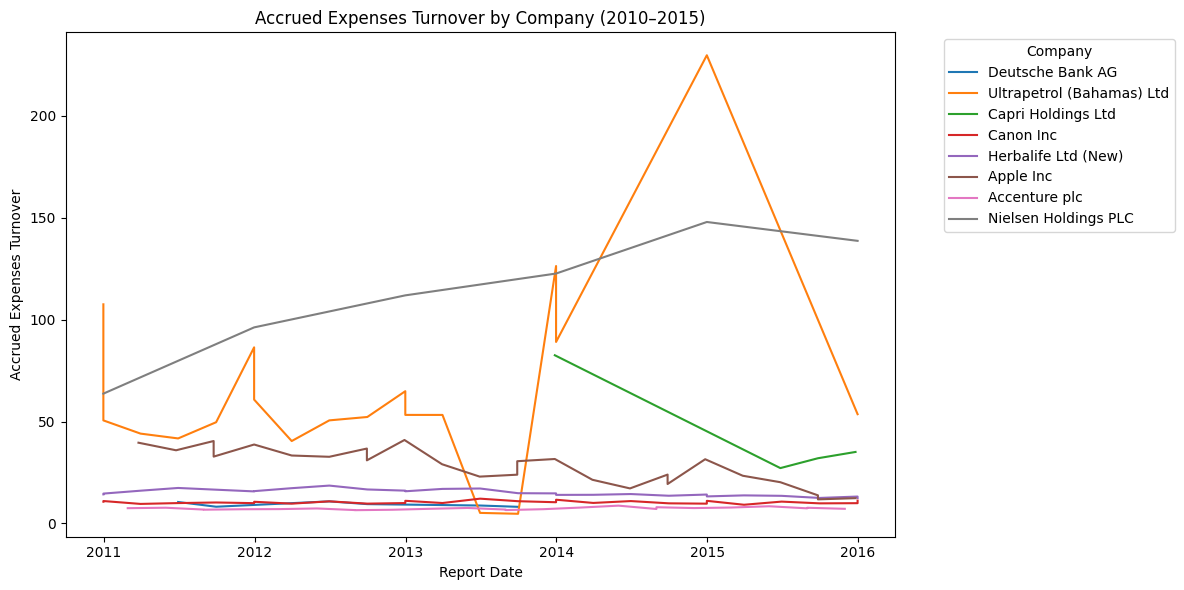

In [13]:
plt.figure(figsize=(12, 6))

for company in relevant_data["company_name"].unique():
    company_data = relevant_data[
        relevant_data["company_name"] == company
    ].sort_values("report_date")

    plt.plot(
        company_data["report_date"],
        company_data["amount"],
        label=company
    )

plt.title("Accrued Expenses Turnover by Company (2010–2015)")
plt.xlabel("Report Date")
plt.ylabel("Accrued Expenses Turnover")

plt.legend(
    title="Company",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Trend Observation

The chart shows that Accrued Expenses Turnover varies considerably between companies during the 2010–2015 period.

Some companies show relatively stable values, while others have larger increases or decreases over time. This suggests that companies manage their accrued expenses differently.


## Geographical Region Analysis

The data can also be grouped by country to compare the average Accrued Expenses Turnover across different geographical regions.

For this analysis, the average `amount` will be calculated for each country.


In [14]:
country_avg = updated_df.groupby("country_name")["amount"].mean()

country_avg

,amount
country_name,
Bahamas,66.515369
Cayman Islands,15.060796
Germany,9.288999
Ireland,7.264400
Japan,10.376605
United Kingdom,44.166750
United States of America,44.377585


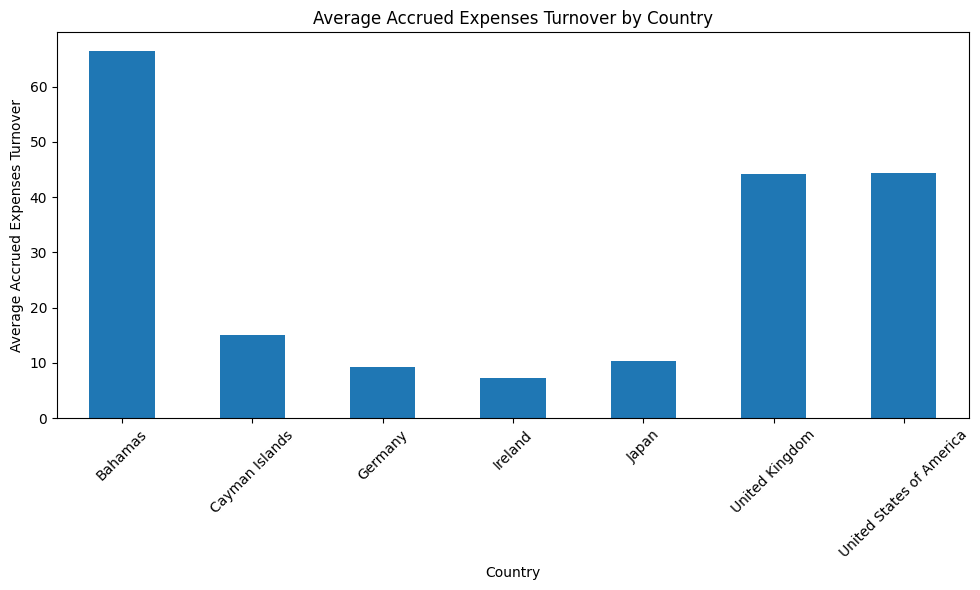

In [15]:
plt.figure(figsize=(10, 6))

country_avg.plot(kind="bar")

plt.title("Average Accrued Expenses Turnover by Country")
plt.xlabel("Country")
plt.ylabel("Average Accrued Expenses Turnover")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
country_avg

,amount
country_name,
Bahamas,66.515369
Cayman Islands,15.060796
Germany,9.288999
Ireland,7.264400
Japan,10.376605
United Kingdom,44.166750
United States of America,44.377585


## Conclusion

In this project, financial data was retrieved from the Nasdaq Data Link API and converted into a Pandas DataFrame for analysis.

The analysis focused on Accrued Expenses Turnover. The data showed considerable differences between companies and countries. During the 2010–2015 period, some companies had relatively stable values, while others showed larger changes over time.

When comparing countries, the Bahamas had the highest average Accrued Expenses Turnover in this dataset, at approximately **66.52**. The United States and the United Kingdom also had relatively high averages, at approximately **44.38** and **44.17** respectively.

These results show how Python, Pandas, and Matplotlib can be used together to retrieve, clean, analyze, and visualize financial data from an API.
